# 01. Market Snapshot

This notebook introduces the dataset used in the Barcelona housing market analysis.

The objective is to define the scope, structure, and quality of the data before moving into modeling and analytical modules.

The dataset is built from publicly available housing listings and represents the observable supply of flats in Barcelona at the time of data collection.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.paths import PROCESSED_DIR

## 1. Load processed dataset

The dataset used in this project is generated through a structured data preparation pipeline, which transforms raw listing data into a clean and analysis-ready dataset.

In [2]:
df = pd.read_csv(PROCESSED_DIR / "listings_processed.csv")
df.shape

(4438, 96)

In [3]:
df.head()

,id,type,subtype,external_contract,invalid,new,advertiser,description,value,reduced,...,Bodega,Sauna,Cuarto lavado plancha,Energía Solar,Muebles de diseño,Música ambiental,Pista de Tenis,Porche cubierto,Sala de cine,price_per_sqm
0,181424803,2,1,False,False,False,BARNAQUATRE,Piso reformado a estrenar de cuatro habitacion...,475000,0,...,False,False,False,False,NaN,NaN,False,NaN,NaN,5163.043478
1,181170834,2,1,False,False,False,SANTA TERESA EXPORTACIONES SL.,Situado en una de las zonas más céntricas de B...,655000,35000,...,False,False,False,False,NaN,NaN,False,NaN,NaN,6359.223301
2,181107559,2,1,False,False,False,MONIKA RÜSCH,Fantástica oportunidad de venta en una de las ...,395000,0,...,False,False,False,False,NaN,NaN,False,NaN,NaN,7452.830189
3,177615105,2,1,False,False,False,Inmuebla Retail Sociedad Limitada,Se vende un piso de 100 m2 con 2 habitaciones ...,495000,55000,...,False,False,False,False,NaN,NaN,False,NaN,NaN,4500.000000
4,181799186,2,1,False,False,False,GAUDI HOUSE,Gaudi House tiene el agrado de presentarles es...,226000,10000,...,False,False,False,False,NaN,NaN,False,NaN,NaN,2790.123457


## 2. Data preparation pipeline

The dataset is constructed through the following steps:

- Raw listing files are collected and concatenated.
- Exact duplicated rows are removed.
- Redundant descriptive columns are standardized.
- Amenity indicators are converted into boolean variables.
- Invalid records (missing or non-positive values) are filtered.
- Unrealistic values (e.g. extreme surface values) are excluded.
- Irrelevant raw fields are removed.
- Price outliers are filtered using an interquartile range (IQR) method.
- Potential duplicate listings are removed based on property characteristics.
- Derived features such as price per square meter are computed.

This pipeline ensures consistency, reduces noise, and prepares the dataset for downstream modeling and analysis.

## 3. Dataset overview

In [4]:
summary = pd.DataFrame({
    "Metric": ["Number of listings", "Number of features", "Median price", "Median surface", "Median price per sqm"],
    "Value": [df.shape[0], df.shape[1], df["value"].median(), df["surface"].median(), df["price_per_sqm"].median()]
})

summary

,Metric,Value
0,Number of listings,4438.000000
1,Number of features,96.000000
2,Median price,396000.000000
3,Median surface,88.000000
4,Median price per sqm,4518.651529


The dataset contains a substantial number of listings, providing a structured view of the observable housing supply. Median values indicate the typical scale of prices and property sizes, which serve as reference points for subsequent analysis.

In [5]:
df.dtypes.value_counts()

bool       49
object     19
int64      14
float64    14
Name: count, dtype: int64

## 4. Key variables

The main variables used throughout the analysis are:

- `value`: asking price of the listing
- `surface`: property size in square meters
- `price_per_sqm`: price per square meter
- `rooms`: number of rooms
- `bathrooms`: number of bathrooms

These variables form the basis for valuation modeling, spatial comparisons, and affordability analysis.

In [6]:
key_columns = ["value", "surface", "price_per_sqm", "rooms", "bathrooms"]
df[key_columns].describe()

,value,surface,price_per_sqm,rooms,bathrooms
count,4.438000e+03,4438.000000,4438.000000,4438.000000,4438.000000
mean,4.773758e+05,99.601172,4760.158314,2.847454,1.611762
std,2.805223e+05,45.999990,1804.521111,1.090840,0.727772
min,3.990000e+04,20.000000,568.283582,0.000000,0.000000
25%,2.650000e+05,70.000000,3527.900886,2.000000,1.000000
50%,3.960000e+05,88.000000,4518.651529,3.000000,2.000000
75%,6.433000e+05,119.000000,5729.166667,3.000000,2.000000
max,1.300000e+06,515.000000,15806.451613,8.000000,10.000000


## 5. Variable distributions

The following plots summarize the distribution of the main numerical variables in the dataset.

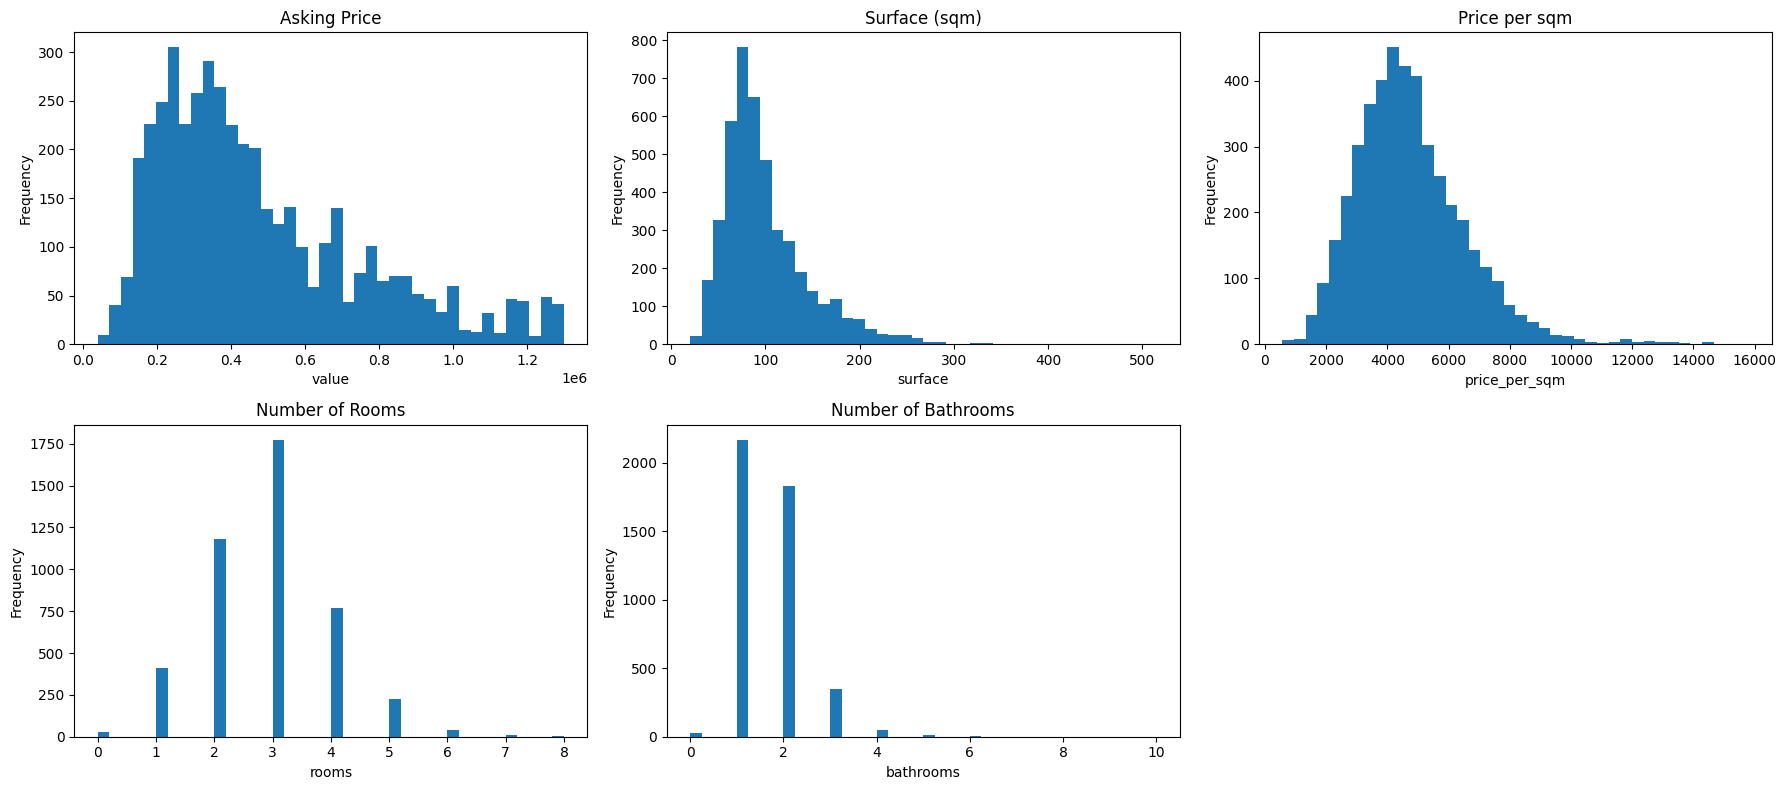

In [ ]:
def plot_distributions(df, variables, n_cols=3):
    import matplotlib.pyplot as plt
    import math

    n_plots = len(variables)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, (col, title) in enumerate(variables):
        axes[i].hist(df[col].dropna(), bins=40)
        axes[i].set_title(title)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    # Turn off unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

variables = [("value", "Asking Price"), ("surface", "Surface (sqm)"), ("price_per_sqm", "Price per sqm"), ("rooms", "Number of Rooms"), ("bathrooms", "Number of Bathrooms"),]

plot_distributions(df, variables)

1. The distribution of listing prices is right-skewed, with most properties concentrated in mid-range values and a long tail corresponding to high-end listings.
2. Property surface also shows a right-skewed distribution, with the majority of listings concentrated around typical residential sizes and fewer large properties.
3. Price per square meter follows a unimodal distribution, indicating a relatively consistent pricing structure with variability across locations and property characteristics.
4. The number of rooms is concentrated around 2 to 4 rooms, reflecting the most common residential configurations.
5. The number of bathrooms is primarily concentrated around 1 and 2, which aligns with typical housing layouts.

Overall, these distributions are consistent with expected patterns in urban housing markets and confirm that the dataset captures a realistic representation of listing supply.

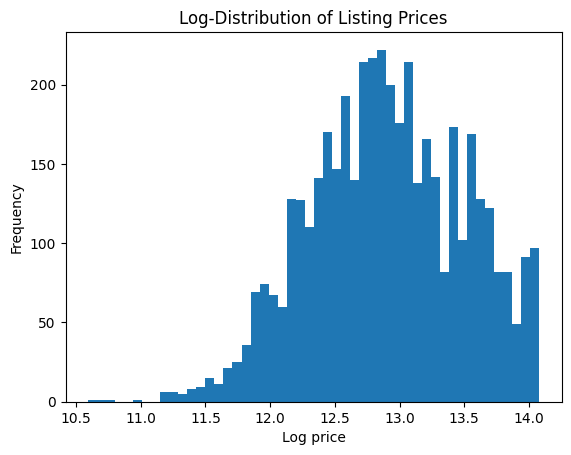

In [8]:
plt.hist(np.log(df["value"]), bins=50)
plt.title("Log-Distribution of Listing Prices")
plt.xlabel("Log price")
plt.ylabel("Frequency")
plt.show()

The log-transformed distribution shows a more symmetric shape, confirming the strong right skew in raw prices. This supports the use of log-scale transformations in the valuation modeling stage.

## 6. Missing values

In [9]:
missing = df.isna().mean().sort_values(ascending=False).rename("missing_ratio").to_frame()
missing.head(15)

,missing_ratio
level6,1.000000
Música ambiental,1.000000
Sala de cine,1.000000
Muebles de diseño,1.000000
Porche cubierto,0.999324
multimedia_type_5,0.967328
multimedia_type_12,0.878324
multimedia_type_6,0.865480
multimedia_type_21,0.833258
hotWater_type_desc,0.689274


Missing values are concentrated in specific variables, which is expected given the nature of listing data. Core variables such as price and surface are complete after filtering, ensuring reliability for the main analytical components.

## 7. Data scope and limitations

- Prices correspond to asking prices, not final transaction prices.
- The dataset reflects visible housing supply at a given point in time.
- Some properties may appear multiple times due to reposting or platform behavior.
- Data fields may vary in completeness and accuracy depending on the listing.
- The dataset does not include off-market transactions or private sales.

As a result, the analysis should be interpreted as a structured view of listing-market dynamics rather than a complete representation of the housing market.

## 8. Module output

The output of this module is the processed dataset:

`data/processed/listings_processed.csv`

This dataset is used as input for:

- Property valuation modeling
- Relative price positioning analysis
- Affordability scenario analysis